In [2]:
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from keras.models import Model
import seaborn as sns

import sys
sys.path.append('..')

In [3]:
from src.Components.data_processing import data_process
from src.utils import *

In [4]:
file_direc = '../datasets/Dodgers/101-freeway-traffic.test.out'
column_names = ['value', 'anomaly']
data = pd.read_csv(file_direc, names=column_names)
data.head()

,value,anomaly
0,-1,1
1,-1,1
2,-1,1
3,-1,1
4,-1,1


<Axes: xlabel='None', ylabel='value'>

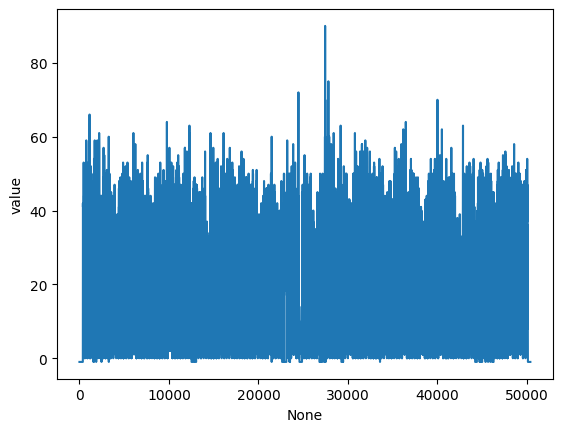

In [5]:
sns.lineplot(x=data.index, y=data['value'])

In [6]:
train_data, test_data = train_test_anomaly(data, shuffle=False)

In [7]:
train_data['value'].to_numpy().reshape(-1, 1)

array([[23],
       [42],
       [37],
       ...,
       [22],
       [10],
       [15]])

In [8]:
scaler = StandardScaler()
scaler = scaler.fit(train_data[['value']])

In [9]:
windowed_data = data_process(df=data)

In [10]:
train_data['train_norm'] = scaler.transform(train_data[['value']])
test_data['test_norm'] = scaler.transform(test_data[['value']])

In [11]:
seq_size = 50

def to_sequences(x, y, seq_size=1):

    x_values = []
    y_values = []

    for i in range(len(x) - seq_size):

        x_values.append(x.iloc[i:(i+seq_size)])
        y_values.append(y.iloc[i+seq_size])
    
    return np.array(x_values), np.array(y_values)


In [12]:
trainX, trainY = to_sequences(train_data[['train_norm']],train_data['train_norm'], seq_size=seq_size)

In [13]:

print(trainX.shape[2])
print(trainY.shape)

1
(35230,)


### Implementing the LSTM-VAE

In [14]:
model = Sequential()

model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(rate=0.2))

model.add(RepeatVector(trainX.shape[1]))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(trainX.shape[2])))
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128)               66560     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 repeat_vector (RepeatVecto  (None, 50, 128)           0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 50, 128)           131584    
                                                                 
 dropout_1 (Dropout)         (None, 50, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 50, 1)             129       
 ributed)                                               

In [15]:
history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
372/991 [==========>...................] - ETA: 43s - loss: 0.8634

KeyboardInterrupt: 

In [16]:
tf.config.list_physical_devices('GPU')

[]